# Prédiction de la gravité des accidents routiers

**Auteur : El Cheriaa El Manssouri Iyad

# Machine Learning – Analyse de la gravité des accidents

Ce notebook présente l'application de modèles de Machine Learning pour analyser et classifier la gravité des usagers impliqués dans des accidents de la route en France en 2024.

Deux modèles sont étudiés :
- Decision Tree
- Random Forest

## Objectif

L'objectif est de déterminer dans quelle mesure les caractéristiques des accidents et des usagers permettent de classifier la gravité des conséquences pour les usagers impliqués.

La variable cible est `grav`, qui correspond à la gravité de l'accident pour l'usager :
- 1 : Indemne
- 2 : Tué
- 3 : Blessé hospitalisé
- 4 : Blessé léger

## Préparation des données

Les données utilisées proviennent du fichier `usagers_prepares.csv`, préparé lors de l'étape précédente du projet.

Les variables sélectionnées sont les caractéristiques des usagers et des accidents utilisées comme variables d'entrée du modèle. La variable `grav` constitue la variable cible.

In [1]:
import pandas as pd

# Chargement des données préparées
usagers = pd.read_csv("../data/processed/usagers_prepares.csv")

usagers.head()

,Num_Acc,grav,sexe,an_nais,catu,age,jour,mois,hrmn,lum,agg,atm,catr,lum_label,atm_label,agg_label,catr_label,grav_label,sexe_label,catu_label
0,202400000001,3,1,2003.0,1,21.0,25,3,07:40,2,1,5,3,Crépuscule ou aube,Brouillard ou fumée,Hors agglomération,Route départementale,Blessé hospitalisé,Masculin,Conducteur
1,202400000001,1,1,1997.0,1,27.0,25,3,07:40,2,1,5,3,Crépuscule ou aube,Brouillard ou fumée,Hors agglomération,Route départementale,Indemne,Masculin,Conducteur
2,202400000002,3,2,1927.0,3,97.0,20,3,15:05,1,2,7,4,Plein jour,Temps éblouissant,En agglomération,Voie communale,Blessé hospitalisé,Féminin,Piéton
3,202400000002,1,1,1987.0,1,37.0,20,3,15:05,1,2,7,4,Plein jour,Temps éblouissant,En agglomération,Voie communale,Indemne,Masculin,Conducteur
4,202400000003,4,2,2007.0,2,17.0,22,3,19:30,2,1,1,4,Crépuscule ou aube,Normale,Hors agglomération,Voie communale,Blessé léger,Féminin,Passager


### Variables utilisées

Les variables suivantes sont utilisées comme entrées du modèle :

- `age`
- `sexe`
- `catu`
- `jour`
- `mois`
- `hrmn`
- `lum`
- `agg`
- `atm`
- `catr`

La variable cible est `grav`.

In [2]:
variables = [
    "age",
    "sexe",
    "catu",
    "jour",
    "mois",
    "hrmn",
    "lum",
    "agg",
    "atm",
    "catr"
]

cible = "grav"

data_ml = usagers[variables + [cible]].copy()

# Suppression des lignes avec des valeurs manquantes
data_ml = data_ml.dropna()

print("Nombre de lignes :", len(data_ml))
print("Nombre de variables :", len(variables))

Nombre de lignes : 122608
Nombre de variables : 10


### Transformation de l'heure

La variable `hrmn` contient l'heure et les minutes de l'accident sous la forme `HH:MM`.

Pour l'utiliser dans le modèle, seule l'heure est conservée dans une nouvelle variable `heure`.

In [3]:
# Extraction de l'heure à partir de hrmn
data_ml["heure"] = pd.to_datetime(
    data_ml["hrmn"],
    format="%H:%M"
).dt.hour

# Suppression de la variable hrmn originale
data_ml = data_ml.drop(columns=["hrmn"])

data_ml.head()

,age,sexe,catu,jour,mois,lum,agg,atm,catr,grav,heure
0,21.0,1,1,25,3,2,1,5,3,3,7
1,27.0,1,1,25,3,2,1,5,3,1,7
2,97.0,2,3,20,3,1,2,7,4,3,15
3,37.0,1,1,20,3,1,2,7,4,1,15
4,17.0,2,2,22,3,2,1,1,4,4,19


## Séparation des données

Les variables explicatives sont séparées de la variable cible `grav`.

Les données sont ensuite divisées en deux ensembles :
- 80 % pour l'entraînement du modèle ;
- 20 % pour le test.

In [4]:
from sklearn.model_selection import train_test_split

# Séparation des variables d'entrée et de la cible
X = data_ml.drop(columns=["grav"])
y = data_ml["grav"]

# Séparation des données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Données d'entraînement :", X_train.shape)
print("Données de test :", X_test.shape)

Données d'entraînement : (98086, 10)
Données de test : (24522, 10)


## Prétraitement des variables

Certaines variables sont catégorielles et doivent être transformées avant d'être utilisées par les modèles.

Un encodage One-Hot est appliqué aux variables catégorielles.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Variables catégorielles
variables_categorielles = [
    "sexe",
    "catu",
    "lum",
    "agg",
    "atm",
    "catr"
]

# Préprocesseur
preprocesseur = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categorielles
        )
    ],
    remainder="passthrough"
)

## Modèle Decision Tree

Un arbre de décision est utilisé comme premier modèle de classification afin de servir de référence pour comparer ses performances avec celles du Random Forest.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Création du modèle Decision Tree
modele_arbre = Pipeline(
    steps=[
        ("preprocessing", preprocesseur),
        (
            "model",
            DecisionTreeClassifier(random_state=42)
        )
    ]
)

# Entraînement du modèle
modele_arbre.fit(X_train, y_train)

print("Modèle Decision Tree entraîné avec succès.")

Modèle Decision Tree entraîné avec succès.


## Évaluation du Decision Tree

Les prédictions du modèle sont comparées aux valeurs réelles de l'ensemble de test à l'aide de plusieurs métriques : l'accuracy, la précision, le rappel et le F1-score.

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prédictions sur les données de test
predictions_arbre = modele_arbre.predict(X_test)

# Évaluation du modèle
print("Accuracy :", accuracy_score(y_test, predictions_arbre))

print("\nRapport de classification :")
print(classification_report(y_test, predictions_arbre))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, predictions_arbre))

Accuracy : 0.41566756382024306

Rapport de classification :
              precision    recall  f1-score   support

           1       0.48      0.47      0.48     10070
           2       0.10      0.10      0.10       686
           3       0.24      0.24      0.24      3825
           4       0.45      0.44      0.45      9941

    accuracy                           0.42     24522
   macro avg       0.31      0.32      0.32     24522
weighted avg       0.42      0.42      0.42     24522


Matrice de confusion :
[[4781  226 1326 3737]
 [ 208   70  181  227]
 [1276  175  929 1445]
 [3747  264 1517 4413]]


## Modèle Random Forest

Un modèle Random Forest est ensuite entraîné afin de comparer ses performances avec celles du Decision Tree.

Le modèle utilise plusieurs arbres de décision et prend en compte le déséquilibre des classes grâce à `class_weight="balanced"`.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Création du modèle Random Forest
modele_foret = Pipeline(
    steps=[
        ("preprocessing", preprocesseur),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Entraînement du modèle
modele_foret.fit(X_train, y_train)

print("Modèle Random Forest entraîné avec succès.")

Modèle Random Forest entraîné avec succès.


## Évaluation du Random Forest

Les performances du Random Forest sont évaluées sur les mêmes données de test que celles utilisées pour le Decision Tree.

In [9]:
# Prédictions sur les données de test
predictions_foret = modele_foret.predict(X_test)

# Évaluation du modèle
print("Accuracy :", accuracy_score(y_test, predictions_foret))

print("\nRapport de classification :")
print(classification_report(y_test, predictions_foret))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, predictions_foret))

Accuracy : 0.4425821711116548

Rapport de classification :
              precision    recall  f1-score   support

           1       0.50      0.52      0.51     10070
           2       0.12      0.10      0.11       686
           3       0.28      0.34      0.31      3825
           4       0.49      0.42      0.45      9941

    accuracy                           0.44     24522
   macro avg       0.34      0.35      0.34     24522
weighted avg       0.45      0.44      0.44     24522


Matrice de confusion :
[[5277  189 1465 3139]
 [ 192   69  284  141]
 [1200  158 1311 1156]
 [3917  176 1652 4196]]


## Comparaison des modèles

Les deux modèles sont comparés à partir de leur accuracy et de leur F1-score macro.

Le F1-score macro est particulièrement intéressant ici car les classes sont déséquilibrées.

In [10]:
# Calcul des performances
accuracy_arbre = accuracy_score(y_test, predictions_arbre)
accuracy_foret = accuracy_score(y_test, predictions_foret)

rapport_arbre = classification_report(
    y_test,
    predictions_arbre,
    output_dict=True
)

rapport_foret = classification_report(
    y_test,
    predictions_foret,
    output_dict=True
)

f1_macro_arbre = rapport_arbre["macro avg"]["f1-score"]
f1_macro_foret = rapport_foret["macro avg"]["f1-score"]

# Affichage de la comparaison
comparaison = pd.DataFrame({
    "Modèle": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_arbre, accuracy_foret],
    "F1-score macro": [f1_macro_arbre, f1_macro_foret]
})

comparaison

,Modèle,Accuracy,F1-score macro
0,Decision Tree,0.415668,0.315035
1,Random Forest,0.442582,0.344474


## Comparaison des performances

Le Random Forest obtient de meilleures performances que le Decision Tree selon les deux métriques étudiées.

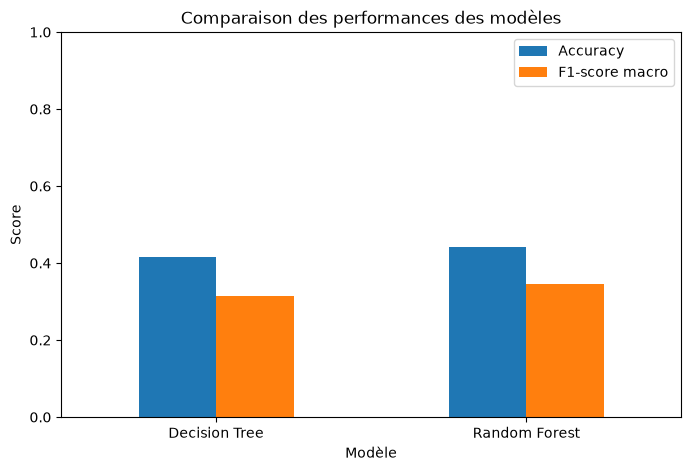

In [11]:
import matplotlib.pyplot as plt

# Graphique de comparaison des performances
comparaison.set_index("Modèle").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

### Interprétation

Le Random Forest obtient de meilleures performances que le Decision Tree. Son accuracy passe de 41,6 % à 44,3 % et son F1-score macro de 0,32 à 0,34. L'amélioration reste toutefois modérée.

## Matrices de confusion

Les matrices de confusion permettent d'observer les classes correctement et incorrectement prédites par chaque modèle.

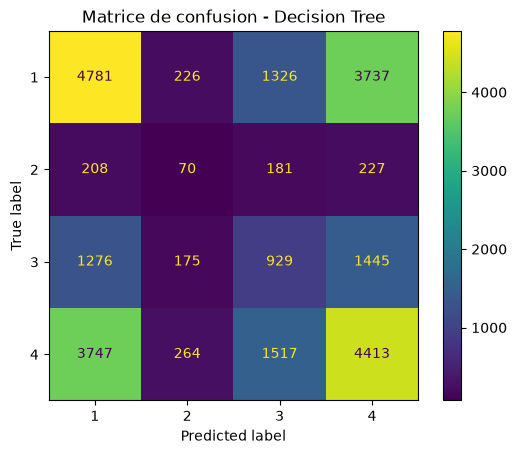

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

# Matrice de confusion du Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_arbre
)

plt.title("Matrice de confusion - Decision Tree")
plt.show()

### Interprétation

Le Decision Tree reconnaît correctement une partie des observations des classes 1 « Indemne » et 4 « Blessé léger ». Cependant, il confond fréquemment ces deux classes ainsi que la classe 3 « Blessé hospitalisé ». La classe 2 « Tué » est particulièrement difficile à identifier, avec seulement 70 observations correctement classées sur 686.

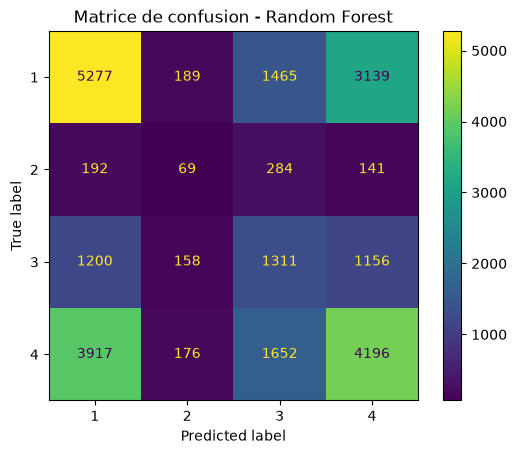

In [13]:
# Matrice de confusion du Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_foret
)

plt.title("Matrice de confusion - Random Forest")
plt.show()

### Interprétation

La matrice montre que le modèle reconnaît relativement bien les classes 1 « Indemne » et 4 « Blessé léger ». En revanche, la classe 2 « Tué » est difficile à identifier, avec seulement 69 observations correctement classées sur 686. Le modèle confond également fréquemment les classes 1, 3 et 4.

## Conclusion

L'application de modèles de Machine Learning a permis d'étudier les relations entre les caractéristiques des usagers, les conditions de l'accident et sa gravité.

Le Random Forest obtient les meilleures performances avec une accuracy de 44,3 % et un F1-score macro de 0,34, contre 41,6 % et 0,32 pour le Decision Tree.

Ces résultats montrent que les données contiennent certains patterns permettant d'estimer la gravité, mais les performances restent limitées. Il n'est donc pas possible de déterminer précisément la gravité à partir des seules variables utilisées.

La classe « Tué » reste notamment difficile à identifier en raison de son faible nombre d'observations. D'autres facteurs pourraient être nécessaires pour améliorer les prédictions.

Le Machine Learning permet ainsi ici d'identifier certaines relations dans les données, tout en mettant en évidence les limites de la prédiction de la gravité des accidents.